In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/Users/ameypatil/Desktop/Tata Power/data/2024 data/2024full.csv')

In [3]:
from sklearn.linear_model import LinearRegression
df = df.dropna(subset=['temp', 'rh', 'wdLoad'])
# Features
X_simple = df[['temp', 'rh']]
y_simple = df['wdLoad']
  # Drop rows with missing values in these columns
# Train model
model_simple = LinearRegression()
model_simple.fit(X_simple, y_simple)

# Predictions
preds = model_simple.predict(X_simple)

In [4]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_simple, preds))
print(f'RMSE: {rmse}')

RMSE: 66.75800227980821


In [5]:
coef_df = pd.DataFrame({
    'Feature': X_simple.columns,
    'Coefficient': model_simple.coef_
})

print(coef_df.sort_values(by='Coefficient', ascending=False))

  Feature  Coefficient
0    temp    18.473892
1      rh     0.385248


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


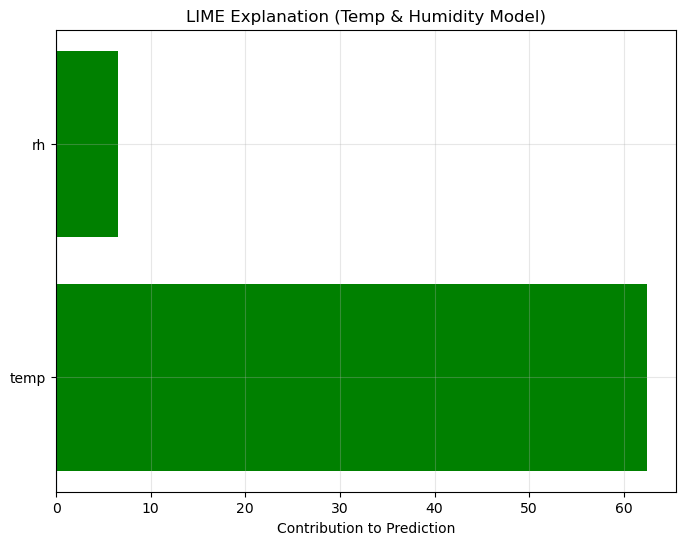

In [6]:
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

explainer = LimeTabularExplainer(
    X_simple.values,
    feature_names=X_simple.columns,
    mode='regression',
    discretize_continuous=False
)

exp = explainer.explain_instance(
    X_simple.iloc[0].values,
    model_simple.predict
)

# Convert to plot
lime_list = exp.as_list()

features = [i[0] for i in lime_list]
values = [i[1] for i in lime_list]

colors = ['green' if v > 0 else 'red' for v in values]

plt.figure(figsize=(8,6))
plt.barh(features, values, color=colors)

plt.xlabel("Contribution to Prediction")
plt.title("LIME Explanation (Temp & Humidity Model)")

plt.axvline(0)
plt.grid(alpha=0.3)

plt.show()

In [7]:
import shap

explainer_shap = shap.LinearExplainer(model_simple, X_simple)
shap_values = explainer_shap(X_simple)

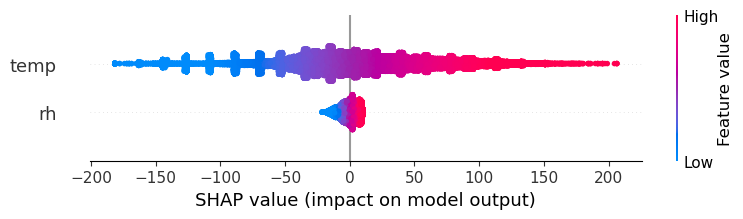

In [8]:
shap.summary_plot(shap_values, X_simple)

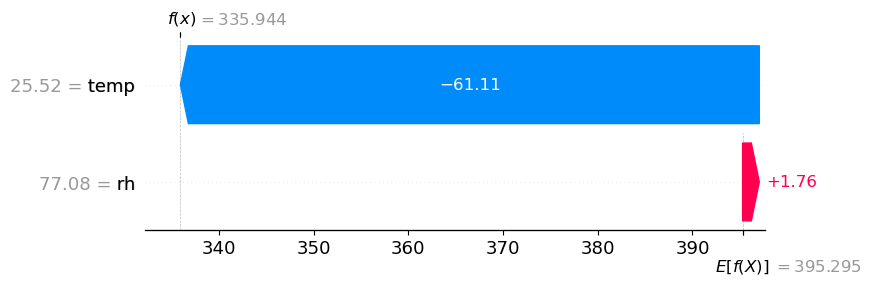

In [9]:
shap.plots.waterfall(shap_values[0])

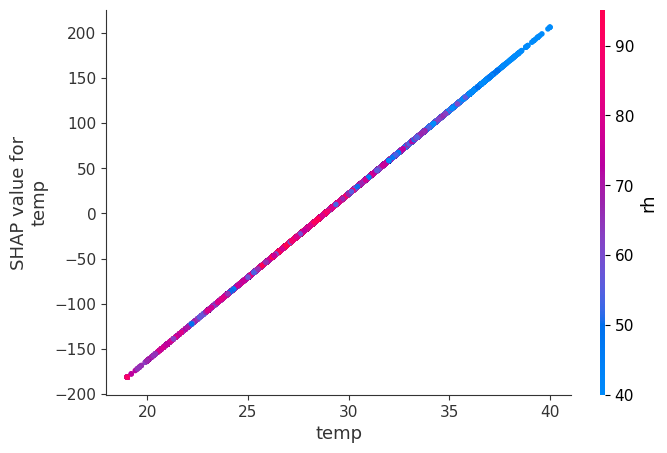

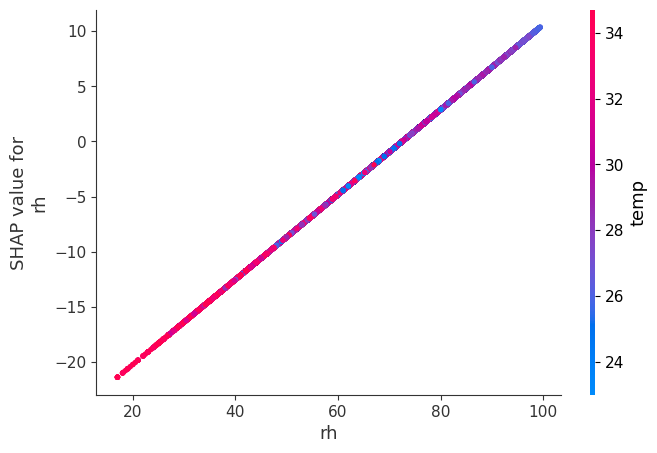

In [10]:
shap.dependence_plot("temp", shap_values.values, X_simple)
shap.dependence_plot("rh", shap_values.values, X_simple)